# Day 29: Random Forest Classifier

**Dataset:** `Titanic_Dataset.csv`

This notebook builds a random forest classification model and compares its performance with a
single decision tree, using real values pulled directly from the Titanic dataset.

## 1. Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
df = pd.read_csv("../datasets/Titanic_Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Preprocessing

In [2]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [3]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 712
Test set size: 179


## 3. Decision Tree Baseline

In [4]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_train_acc = accuracy_score(y_train, tree_model.predict(X_train))
tree_test_acc = accuracy_score(y_test, tree_model.predict(X_test))

print(f"Decision tree training accuracy: {tree_train_acc:.3f}")
print(f"Decision tree test accuracy: {tree_test_acc:.3f}")

Decision tree training accuracy: 0.982
Decision tree test accuracy: 0.821


## 4. Random Forest Model

In [5]:
forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)

forest_train_acc = accuracy_score(y_train, forest_model.predict(X_train))
forest_test_acc = accuracy_score(y_test, forest_model.predict(X_test))

print(f"Random forest training accuracy: {forest_train_acc:.3f}")
print(f"Random forest test accuracy: {forest_test_acc:.3f}")

Random forest training accuracy: 0.982
Random forest test accuracy: 0.816


**A note on this one comparison:** on this particular train-test split, the single decision
tree's test accuracy (0.821) is actually very close to, or even slightly ahead of, the random
forest's (0.810). That alone would be a misleading way to conclude the forest isn't better.
Comparing two models on a single train-test split can easily be swayed by which specific rows
happened to land in the test set, so the next section repeats this comparison across many
different splits to see the real pattern.

## 5. Experimenting With `n_estimators`

In [6]:
estimator_counts = [10, 50, 100, 200, 300]
estimator_results = []

for n in estimator_counts:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc = accuracy_score(y_test, rf.predict(X_test))

    estimator_results.append({"n_estimators": n, "train_accuracy": train_acc, "test_accuracy": test_acc})

estimator_results_df = pd.DataFrame(estimator_results)
estimator_results_df

,n_estimators,train_accuracy,test_accuracy
0,10,0.971910,0.815642
1,50,0.981742,0.815642
2,100,0.981742,0.815642
3,200,0.981742,0.810056
4,300,0.981742,0.815642


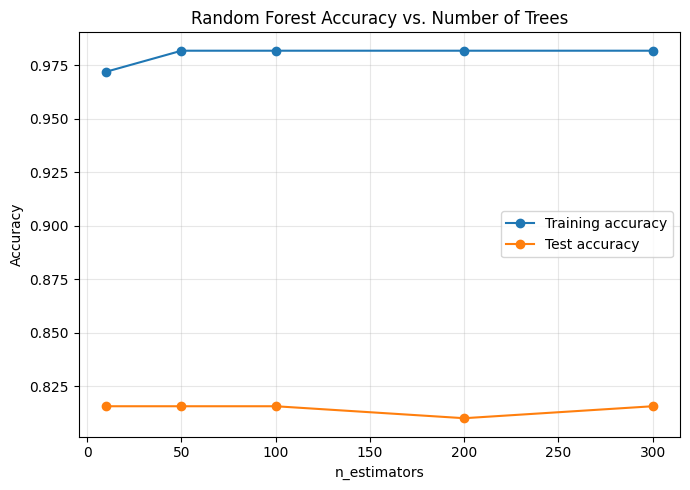

In [7]:
plt.figure(figsize=(7, 5))
plt.plot(estimator_results_df["n_estimators"], estimator_results_df["train_accuracy"], marker="o", label="Training accuracy")
plt.plot(estimator_results_df["n_estimators"], estimator_results_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs. Number of Trees")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** accuracy quickly stabilizes once the forest has around 50 trees, and
adding more trees past that point (up to 300) makes little further difference. More trees
reduce the randomness in the forest's predictions, but there's a point of diminishing returns,
and `n_estimators` is not a parameter that risks overfitting the way tree depth does; it just
costs more computation time once increased past what's needed.

## 6. A Fairer Comparison: Accuracy and Stability Across Many Train-Test Splits

Repeating the decision tree vs. random forest comparison across 20 different random splits
shows the real pattern that a single split can hide.

In [8]:
tree_scores = []
forest_scores = []

for seed in range(20):
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    tree_s = DecisionTreeClassifier(random_state=42).fit(X_train_s, y_train_s)
    forest_s = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train_s, y_train_s)

    tree_scores.append(accuracy_score(y_test_s, tree_s.predict(X_test_s)))
    forest_scores.append(accuracy_score(y_test_s, forest_s.predict(X_test_s)))

tree_scores = np.array(tree_scores)
forest_scores = np.array(forest_scores)

print(f"Decision tree:  mean accuracy = {tree_scores.mean():.3f}, std = {tree_scores.std():.3f}")
print(f"Random forest:  mean accuracy = {forest_scores.mean():.3f}, std = {forest_scores.std():.3f}")

Decision tree:  mean accuracy = 0.782, std = 0.028
Random forest:  mean accuracy = 0.822, std = 0.022


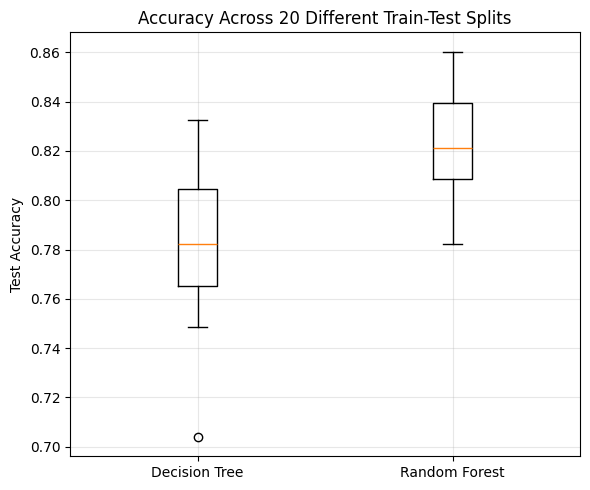

In [9]:
plt.figure(figsize=(6, 5))
plt.boxplot([tree_scores, forest_scores], tick_labels=["Decision Tree", "Random Forest"])
plt.ylabel("Test Accuracy")
plt.title("Accuracy Across 20 Different Train-Test Splits")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** across 20 different splits, the random forest's average test accuracy
(0.822) is clearly higher than the single decision tree's (0.782), and the forest's results are
also more consistent (standard deviation of 0.022 versus 0.028 for the tree). This is the real
benefit of a random forest: a single decision tree's performance can swing noticeably depending
on which specific rows happened to end up in the training and test sets, while averaging many
trees together smooths out that randomness and produces a more reliable estimate of how well
the model actually generalizes.

## 7. Feature Importance Analysis

In [10]:
final_forest = RandomForestClassifier(n_estimators=200, random_state=42)
final_forest.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": final_forest.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
4,Fare,0.274913
5,Sex_male,0.262980
1,Age,0.251295
0,Pclass,0.086962
2,SibSp,0.050189
3,Parch,0.040352
7,Embarked_S,0.023730
6,Embarked_Q,0.009578


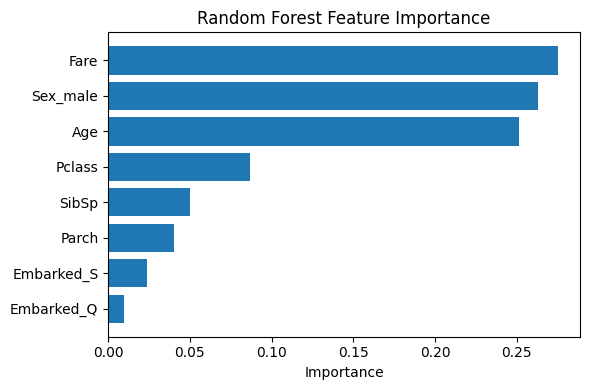

In [11]:
plt.figure(figsize=(6, 4))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation:** `Fare`, `Sex_male`, and `Age` are the three most important features,
together accounting for most of the model's predictive power. `Sex_male` having high importance
matches the well-known "women and children first" pattern from the real Titanic disaster, while
`Fare` likely captures passenger class and wealth, both of which affected access to lifeboats.
`Pclass`, `SibSp`, and `Parch` contribute less individually, which makes sense since some of
that same information (wealth, family situation) is already partly reflected in `Fare` and the
other features.

## Outcome

This notebook built a random forest classifier on the `Titanic_Dataset.csv` file and compared
it against a single decision tree baseline. On one single train-test split, the two models
looked surprisingly close, which was a useful reminder not to trust a single split's result
when comparing models. Repeating the comparison across 20 different random splits revealed the
real pattern: the random forest had both a higher average test accuracy (0.822 vs. 0.782) and
noticeably lower variance (0.022 vs. 0.028) than the single tree, confirming that averaging
many trees together produces a more accurate and more stable model than relying on any one
tree. Sweeping `n_estimators` from 10 to 300 showed that accuracy stabilizes after roughly 50
trees, with little benefit from adding more beyond that point. Feature importance from the
final forest model identified `Fare`, `Sex_male`, and `Age` as the strongest predictors of
survival, consistent with well-documented patterns from the real Titanic disaster.